In [33]:
import pandas as pd
df = pd.read_csv('data/WA_Fn-UseC_-HR-Employee-Attrition.csv')
print(df.shape)          # (1470, 35)
print(df.dtypes)
print(df.isnull().sum())
print(df['Attrition'].value_counts())  # check imbalance

(1470, 35)
Age                         int64
Attrition                     str
BusinessTravel                str
DailyRate                   int64
Department                    str
DistanceFromHome            int64
Education                   int64
EducationField                str
EmployeeCount               int64
EmployeeNumber              int64
EnvironmentSatisfaction     int64
Gender                        str
HourlyRate                  int64
JobInvolvement              int64
JobLevel                    int64
JobRole                       str
JobSatisfaction             int64
MaritalStatus                 str
MonthlyIncome               int64
MonthlyRate                 int64
NumCompaniesWorked          int64
Over18                        str
OverTime                      str
PercentSalaryHike           int64
PerformanceRating           int64
RelationshipSatisfaction    int64
StandardHours               int64
StockOptionLevel            int64
TotalWorkingYears           int64
Tra

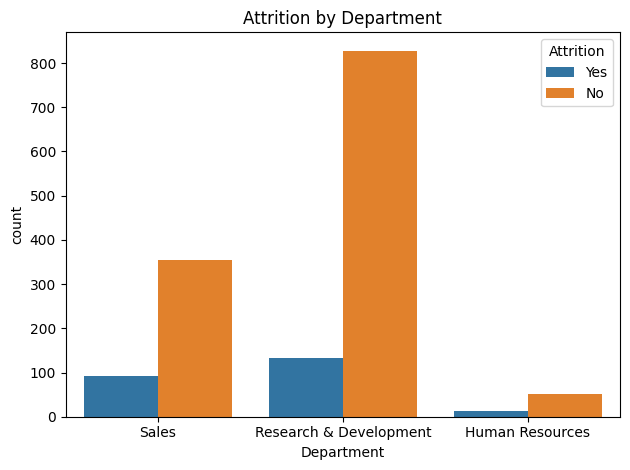

<Axes: >

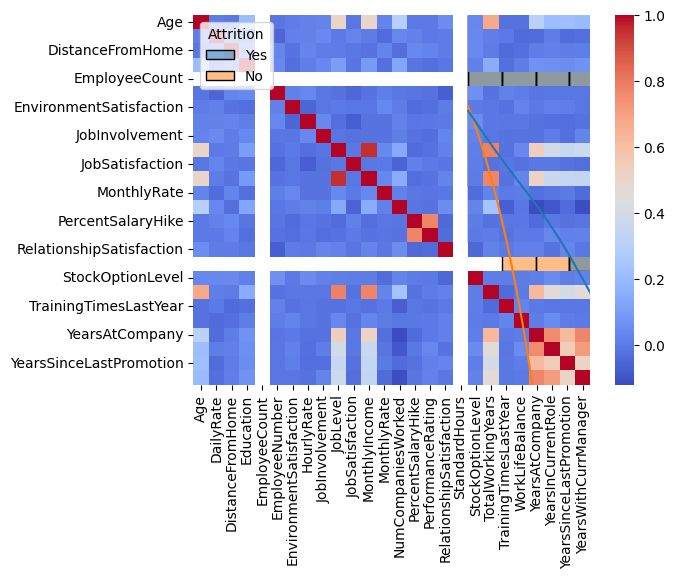

In [34]:
#EDA
import seaborn as sns, matplotlib.pyplot as plt
from pathlib import Path

out = Path("outputs/figures")
out.mkdir(parents=True, exist_ok=True)

# Attrition by department
sns.countplot(data=df, x='Department', hue='Attrition')
plt.title('Attrition by Department')
plt.tight_layout()
plt.savefig(out / "attrition_by_dept.png", dpi=300, bbox_inches="tight")
plt.show()

# Age distribution
sns.histplot(data=df, x='Age', hue='Attrition', kde=True)

# Correlation heatmap (numeric cols only)
sns.heatmap(df.select_dtypes('number').corr(), cmap='coolwarm', annot=False)


In [35]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# Drop constant columns
df.drop(['EmployeeCount','Over18','StandardHours'], axis=1, inplace=True)


In [36]:
# Encode target
df['Attrition'] = df['Attrition'].map({'Yes':1,'No':0})

# Encode categoricals
cat_cols = [
    col for col in df.columns
    if pd.api.types.is_object_dtype(df[col]) or pd.api.types.is_string_dtype(df[col])
]
for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

X = df.drop('Attrition', axis=1)
y = df['Attrition']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [37]:
from pathlib import Path

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

# Scale only for Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

models = {
    'Logistic Regression': LogisticRegression(max_iter=200, C=0.1),
    'Random Forest': RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        min_samples_split=5,
        random_state=42
    ),
    'XGBoost': XGBClassifier(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='logloss',
        random_state=42
    )
}

results = []

for name, model in models.items():
    if name == 'Logistic Regression':
        model.fit(X_train_scaled, y_train)
        preds = model.predict(X_test_scaled)
        probs = model.predict_proba(X_test_scaled)[:,1]
    else:
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
        probs = model.predict_proba(X_test)[:,1]

    results.append({
        'model': name,
        'accuracy': round(accuracy_score(y_test, preds), 4),
        'precision': round(precision_score(y_test, preds, zero_division=0), 4),
        'recall': round(recall_score(y_test, preds, zero_division=0), 4),
        'f1_score': round(f1_score(y_test, preds, zero_division=0), 4),
        'roc_auc': round(roc_auc_score(y_test, probs), 4)
    })

comparison_df = pd.DataFrame(results).sort_values('roc_auc', ascending=False).reset_index(drop=True)

out = Path('outputs')
out.mkdir(parents=True, exist_ok=True)
comparison_df.to_csv(out / 'model_comparison.csv', index=False)

comparison_df

,model,accuracy,precision,recall,f1_score,roc_auc
0,Logistic Regression,0.8810,0.7727,0.3617,0.4928,0.8045
1,Random Forest,0.8299,0.3846,0.1064,0.1667,0.8033
2,XGBoost,0.8707,0.8462,0.2340,0.3667,0.7871


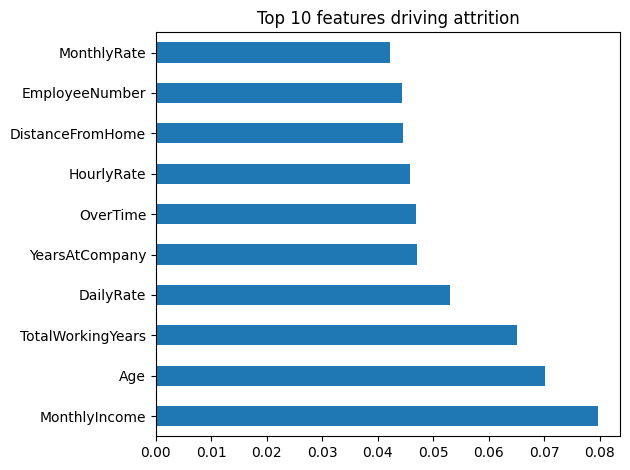

In [38]:
import pandas as pd
rf = models['Random Forest']
feat_imp = pd.Series(rf.feature_importances_, index=X.columns)
feat_imp.nlargest(10).plot(kind='barh', title='Top 10 features driving attrition')
plt.tight_layout()
plt.show()

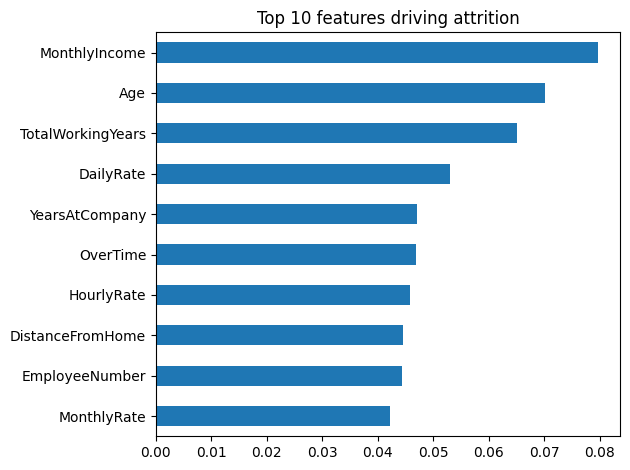

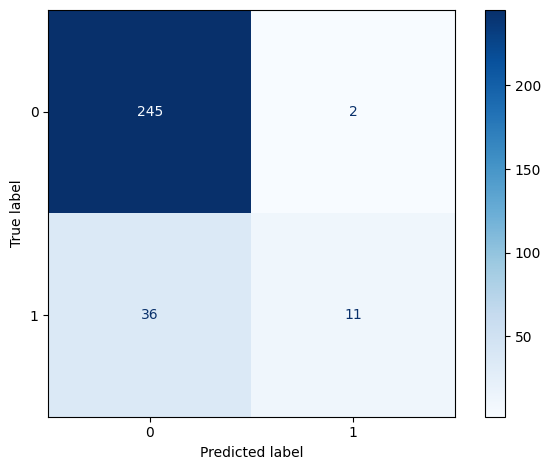

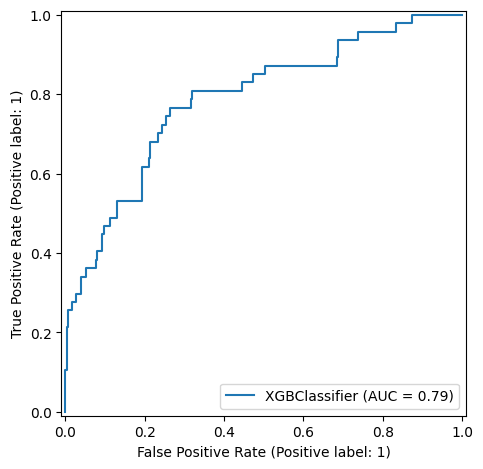

In [39]:
from pathlib import Path
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay

out = Path("outputs/figures")
out.mkdir(parents=True, exist_ok=True)

# 1. Feature importance
rf = models["Random Forest"]
feat_imp = pd.Series(rf.feature_importances_, index=X.columns)
feat_imp.nlargest(10).sort_values().plot(kind="barh", title="Top 10 features driving attrition")
plt.tight_layout()
plt.savefig(out / "feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()

# 2. Confusion matrix for final model
xgb = models["XGBoost"]
ConfusionMatrixDisplay.from_estimator(xgb, X_test, y_test, cmap="Blues")
plt.tight_layout()
plt.savefig(out / "confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

# 3. ROC curve for final model
RocCurveDisplay.from_estimator(xgb, X_test, y_test)
plt.tight_layout()
plt.savefig(out / "roc_curve.png", dpi=300, bbox_inches="tight")
plt.show()
